# QC Filter and Doublet scoring

This data has a bimodal distribution for QC metrics; possibly due to inclusion of non-neuronal cell types

In [1]:
import time
from pathlib import Path
import sys
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import scrublet as scr
import seaborn as sns
import pandas as pd
import numpy as np
import session_info

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
print("Notebook run started at:", time.strftime("%Y-%m-%d %H:%M:%S"))

Notebook run started at: 2025-06-18 10:30:17


In [4]:
# Directories
base_dir = Path("/home/workspace/drg")
data_dir = base_dir / "data"
input_dir = data_dir / "h5ad" / "01_raw"

output_h5ad_dir = data_dir / "h5ad" / "02_filtered"
output_csv_dir = data_dir / "csv" / "scrublet" / "02_filtered"

output_h5ad_dir.mkdir(parents=True, exist_ok=True)
output_csv_dir.mkdir(parents=True, exist_ok=True)

In [5]:
# Files
## input
input_adata = output_h5ad_dir / "GSE254789.h5ad"

## output
scrublet_out = output_csv_dir / "GSE254789-scrublet.csv"
adata_out = output_h5ad_dir / "GSE254789-clean.h5ad"

In [6]:
adata = sc.read_h5ad(input_dir / "GSE254789.h5ad")
#adata = sc.read_h5ad(input_dir / "GSE254789.h5ad")

In [7]:
adata

AnnData object with n_obs × n_vars = 92895 × 28694
    obs: 'GSE', 'GSM', 'sample_number', 'sample_id', 'experiment_id'

In [8]:
adata.X[:10, :10].toarray()

array([[1., 0., 0., 0., 0., 0., 0., 3., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [9]:
adata.var['mt'] = adata.var_names.str.startswith('mt-')
adata.var['ribosomal'] = adata.var_names.str.match(r'^(Rpl|Rps)\d+')

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['mt', 'ribosomal'],
    percent_top=None,
    log1p=False,
    inplace=True
)

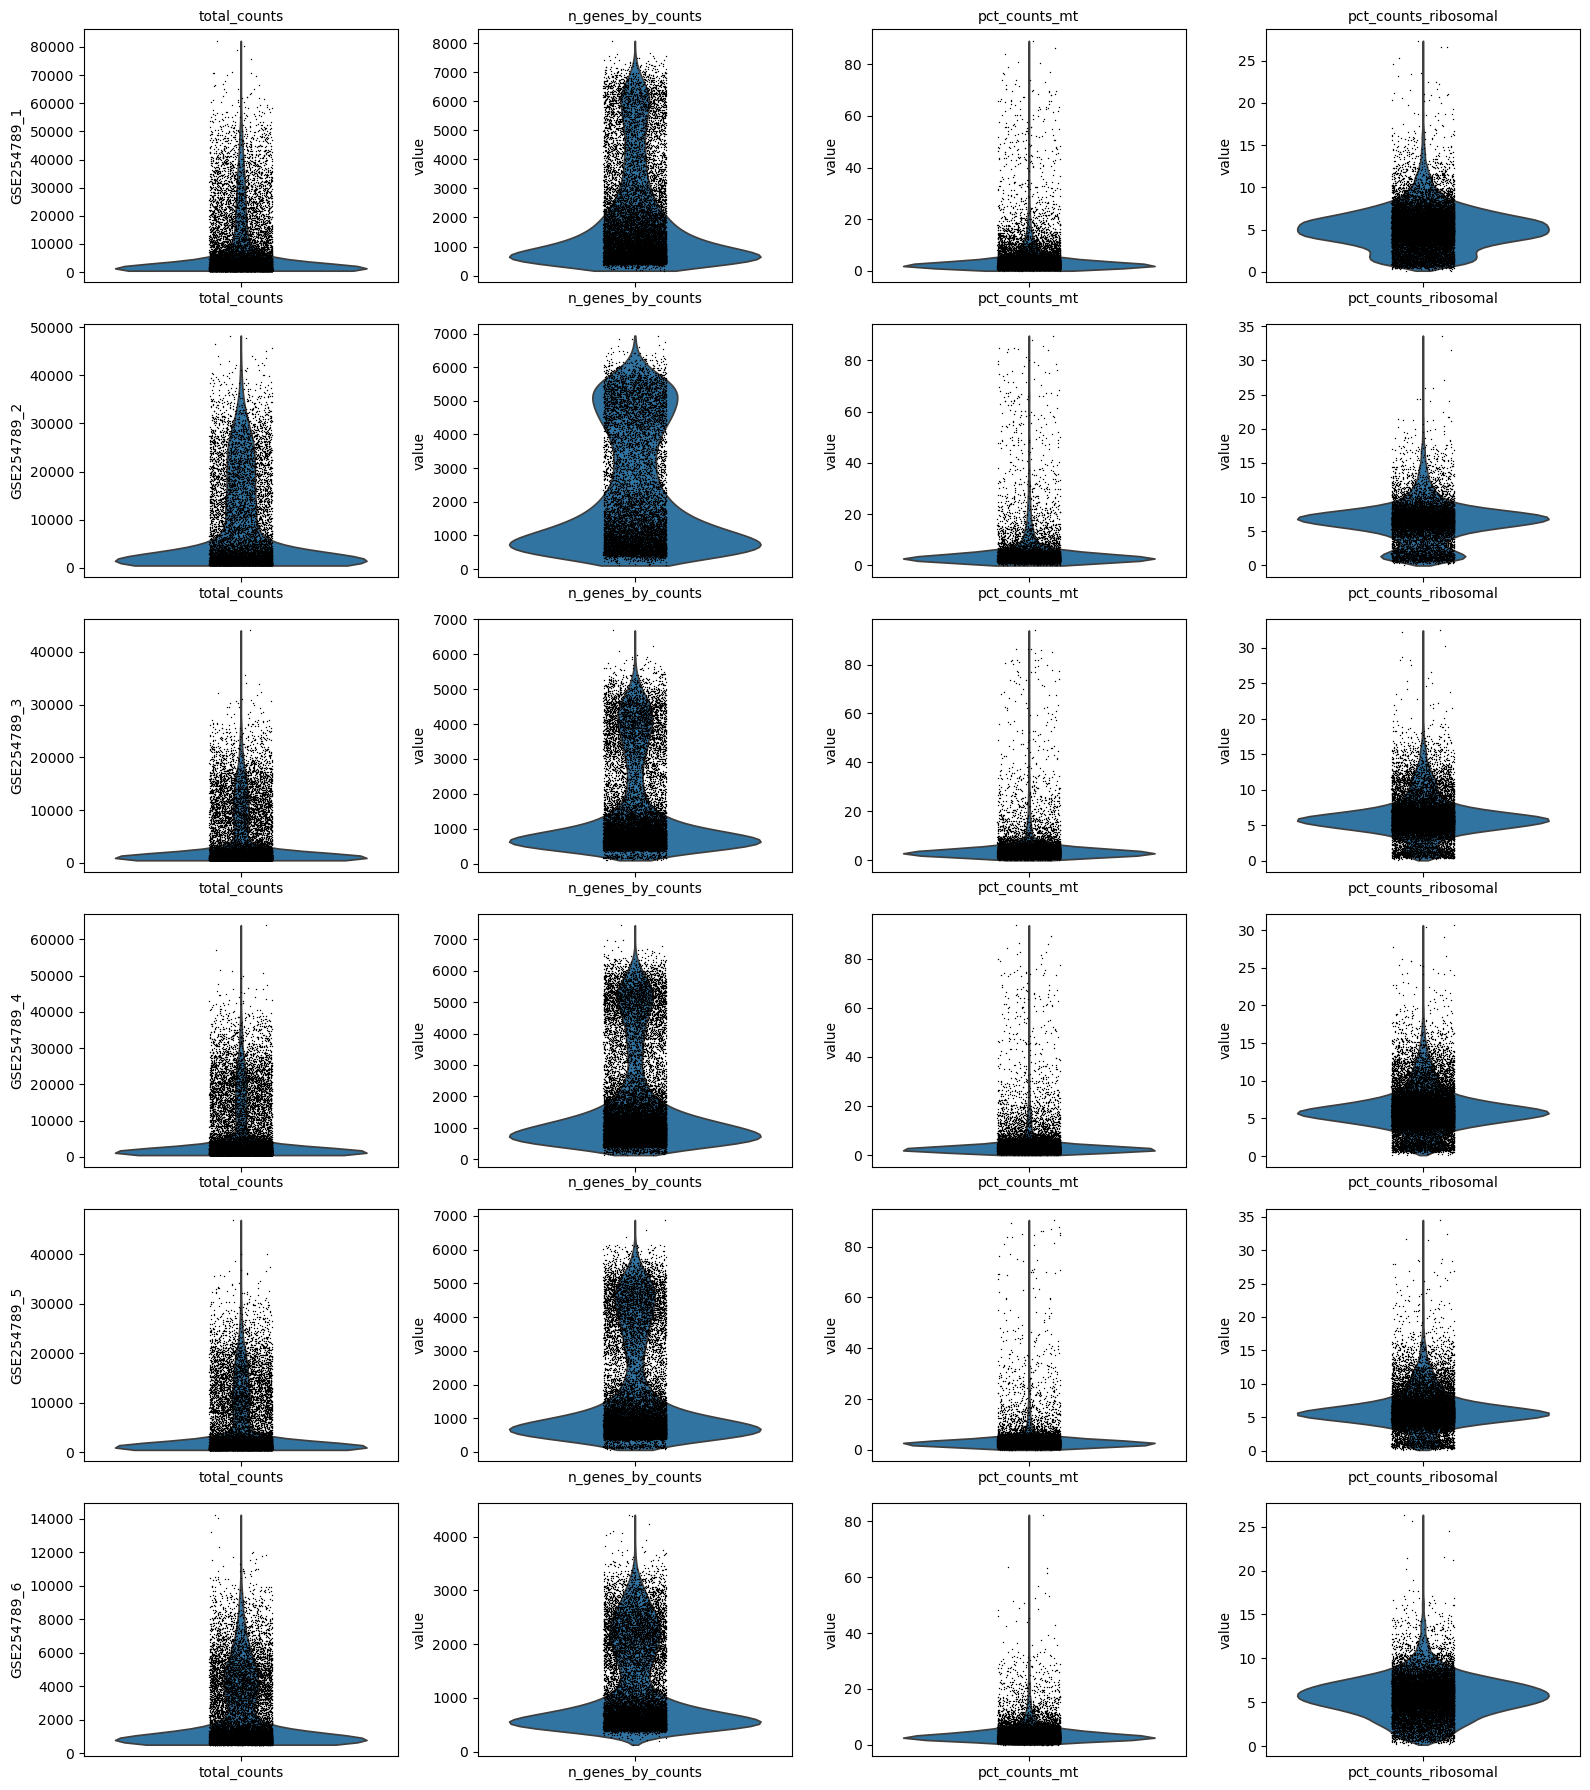

In [10]:
params = ['total_counts', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribosomal']

# Unique sample_ids
sample_ids = adata.obs['sample_id'].unique()
n_samples = len(sample_ids)
n_params = len(params)

# Create figure and axes
fig, axes = plt.subplots(n_samples, n_params, figsize=(4 * n_params, 3 * n_samples), squeeze=False)

# Loop over samples and params
for i, sample_id in enumerate(sample_ids):
    adata_sub = adata[adata.obs['sample_id'] == sample_id]
    
    for j, param in enumerate(params):
        sc.pl.violin(
            adata_sub,
            keys=param,
            ax=axes[i, j],
            show=False
        )
        # Set title for each param column
        if i == 0:
            axes[i, j].set_title(param, fontsize=10)
        # Label rows with sample names
        if j == 0:
            axes[i, j].set_ylabel(sample_id, fontsize=10)

plt.tight_layout()
plt.show()

In [11]:
# Columns to compute medians for
qc_columns = ['total_counts', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribosomal']

# Group by 'experiment_id' and compute medians
qc_medians = adata.obs.groupby('experiment_id')[qc_columns].median()

# Print nicely
print("Median QC metrics per experiment_id:")
print(qc_medians)

Median QC metrics per experiment_id:
               total_counts  n_genes_by_counts  pct_counts_mt  \
experiment_id                                                   
GSE254789            1615.0             1004.0        2.86123   

               pct_counts_ribosomal  
experiment_id                        
GSE254789                  5.779716  


# Filtering

In [12]:
# Basic QC filters
params = [
    ("total_counts", 1000, 0.98),
    ("n_genes_by_counts", 500, 0.98),
]

# Floor thresholds
for param, floor, _ in params:
    adata = adata[adata.obs[param] > floor, :].copy()

# Ceiling thresholds
for param, _, quantile in params:
    threshold = adata.obs[param].quantile(quantile)
    adata = adata[adata.obs[param] < threshold, :].copy()

In [13]:
# mt and ribo fixed thresholds
mito_threshold = 10  # percent
ribosomal_threshold = 20  # percent

# Combined filter
filter_mask = (
    (adata.obs['pct_counts_mt'] < mito_threshold) &
    (adata.obs['pct_counts_ribosomal'] < ribosomal_threshold)
)

adata = adata[filter_mask, :].copy()

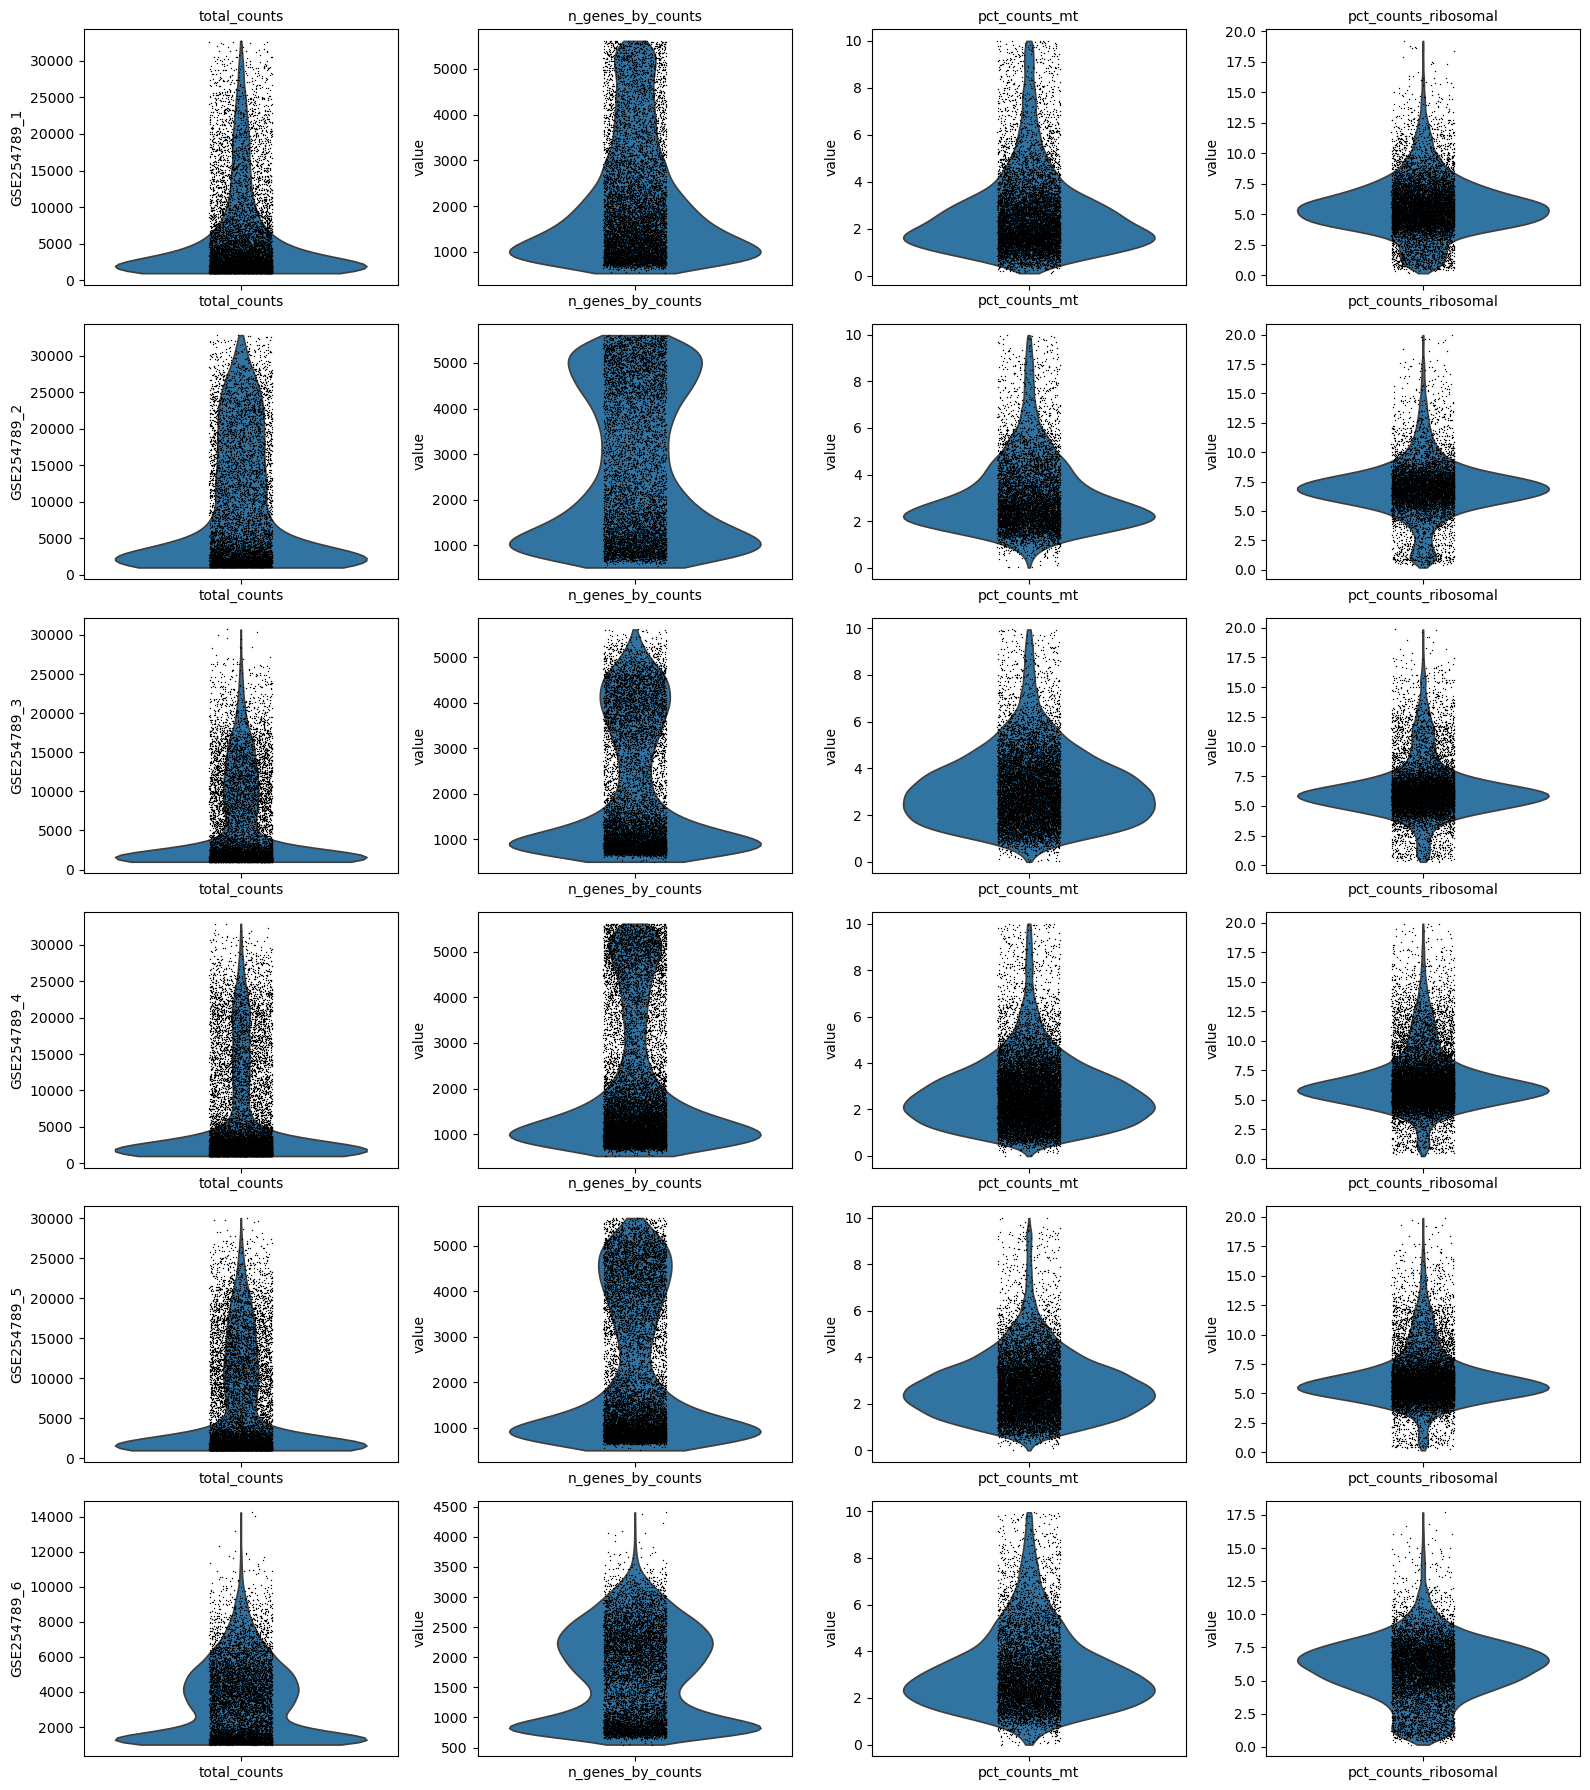

In [14]:
params = ['total_counts', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribosomal']

# Number of parameters
n_params = len(params)

# Get unique sample_ids (for grouping in violin plots)
sample_ids = adata.obs['sample_id'].unique()
n_samples = len(sample_ids)

# Create figure and axes
fig, axes = plt.subplots(n_samples, n_params, figsize=(4 * n_params, 3 * n_samples), squeeze=False)

# Plot per sample_id
for i, sample_id in enumerate(sample_ids):
    adata_sub = adata[adata.obs['sample_id'] == sample_id]

    for j, param in enumerate(params):
        sc.pl.violin(
            adata_sub,
            keys=param,
            ax=axes[i, j],
            show=False
        )
        # Set title for each subplot
        if i == 0:
            axes[i, j].set_title(param, fontsize=10)
        # Label rows with sample names
        if j == 0:
            axes[i, j].set_ylabel(sample_id, fontsize=10)

plt.tight_layout()
plt.show()

## Doublet scoring

In [15]:
def run_scrublet(adata, sample_id_col='sample_id', expected_doublet_rate=0.1):
    scrublet_rows = []

    # Loop over each sample
    for sample_id in adata.obs[sample_id_col].unique():
        adata_sub = adata[adata.obs[sample_id_col] == sample_id].copy()

        # Set up Scrublet
        scrub = scr.Scrublet(adata_sub.X, expected_doublet_rate=expected_doublet_rate, random_state=0)
        doublet_scores, predicted_doublets = scrub.scrub_doublets(
            min_counts=2,
            min_cells=3,
            min_gene_variability_pctl=85,
            n_prin_comps=50
        )

        # Add to adata_sub.obs
        adata_sub.obs['doublet_scores'] = doublet_scores
        adata_sub.obs['predicted_doublets'] = predicted_doublets

        # Plot Histograms
        plt.figure(figsize=(10, 6))
        sns.histplot(scrub.doublet_scores_obs_, bins=30, color="blue", label="Observed", kde=True)
        sns.histplot(scrub.doublet_scores_sim_, bins=30, color="red", label="Simulated", kde=True)
        plt.title(f'Scrublet Doublet Score Distribution for sample_id: {sample_id}')
        plt.xlabel('Doublet Score')
        plt.ylabel('Density')
        plt.legend()
        plt.grid(False)
        plt.show()

        # Save results to DataFrame
        cell_barcodes = adata_sub.obs.index
        for barcode, obs_score, sim_score, pred_doublet in zip(
            cell_barcodes, scrub.doublet_scores_obs_, scrub.doublet_scores_sim_, predicted_doublets
        ):
            scrublet_rows.append({
                'sample_id': sample_id,
                'Cell_Barcode': barcode,
                'Observed_Score': obs_score,
                'Simulated_Score': sim_score,
                'Predicted_Doublet': pred_doublet,
            })

        # Save the columns back to the main adata (optional)
        adata.obs.loc[adata_sub.obs.index, 'doublet_scores'] = doublet_scores
        adata.obs.loc[adata_sub.obs.index, 'predicted_doublets'] = predicted_doublets

    # Final dataframe
    scrublet_df = pd.DataFrame(scrublet_rows)
    return scrublet_df

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.63
Detected doublet rate = 0.1%
Estimated detectable doublet fraction = 11.7%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 1.2%
Elapsed time: 10.1 seconds


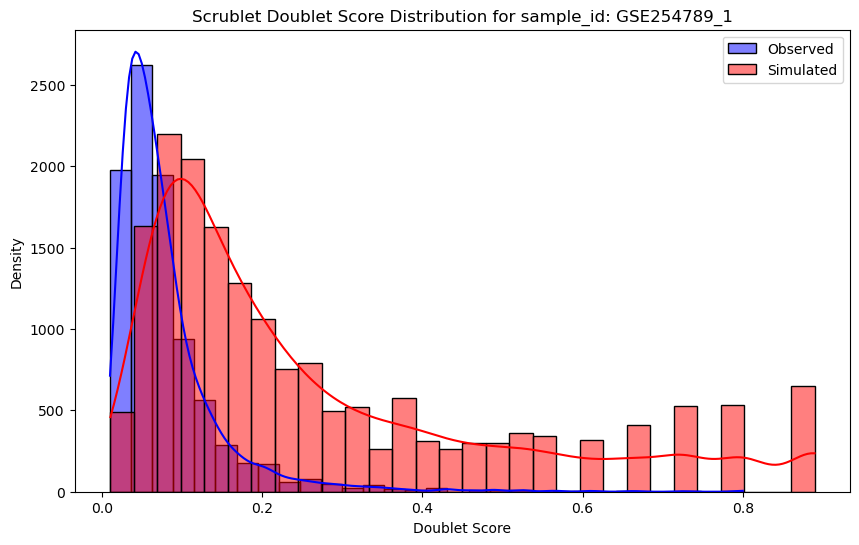

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.62
Detected doublet rate = 0.5%
Estimated detectable doublet fraction = 20.5%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 2.4%
Elapsed time: 7.6 seconds


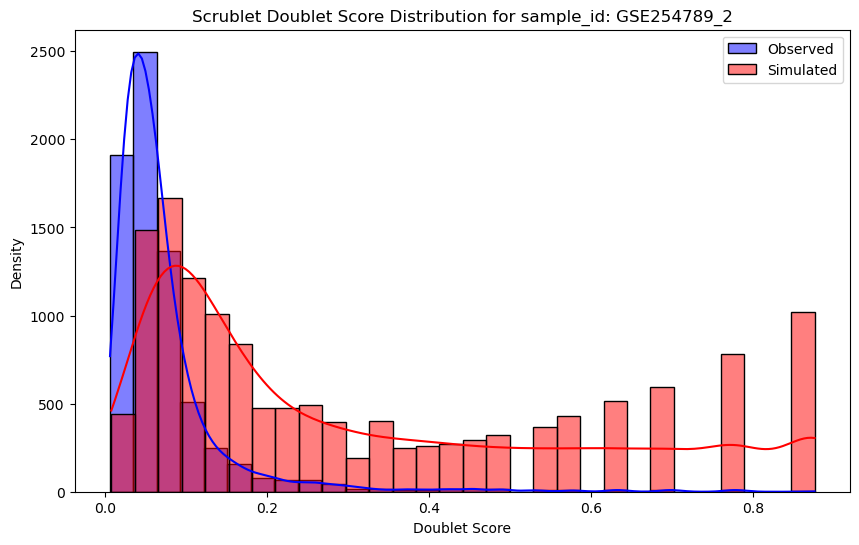

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.41
Detected doublet rate = 2.0%
Estimated detectable doublet fraction = 36.9%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 5.4%
Elapsed time: 11.7 seconds


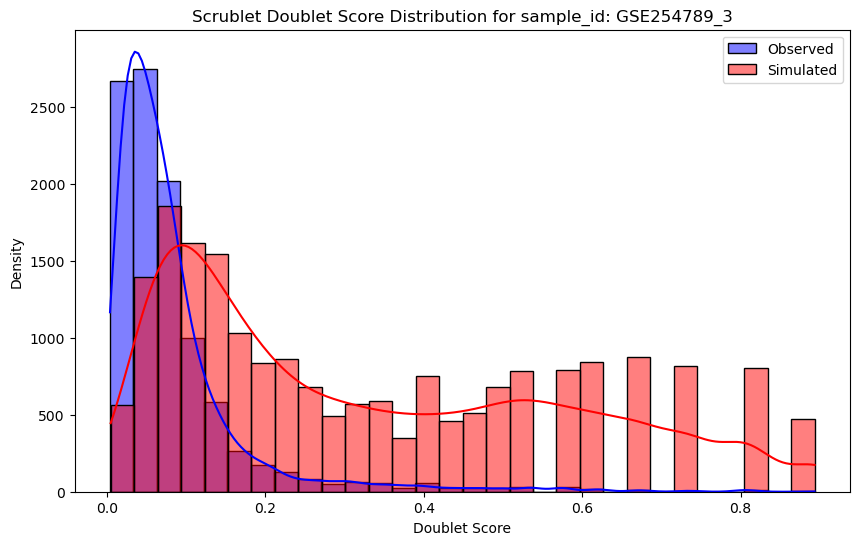

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.46
Detected doublet rate = 1.4%
Estimated detectable doublet fraction = 25.9%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 5.4%
Elapsed time: 17.5 seconds


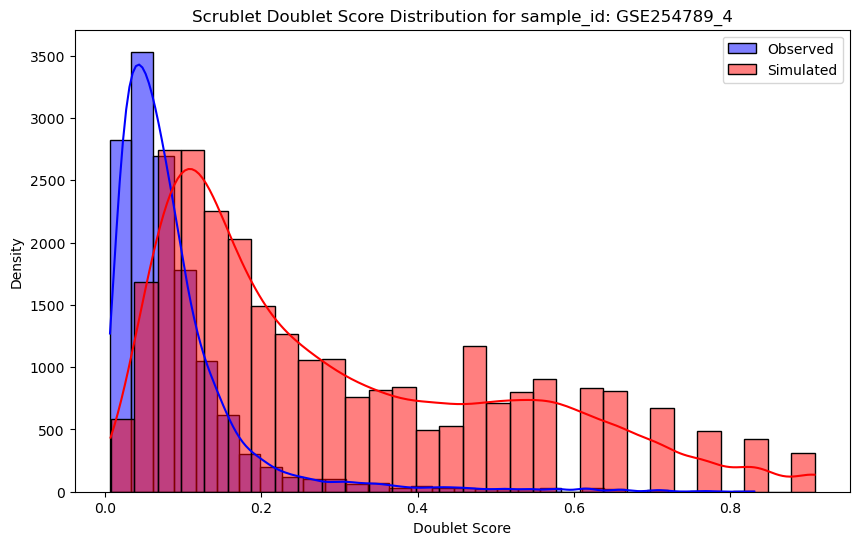

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.31
Detected doublet rate = 4.0%
Estimated detectable doublet fraction = 47.3%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 8.4%
Elapsed time: 13.5 seconds


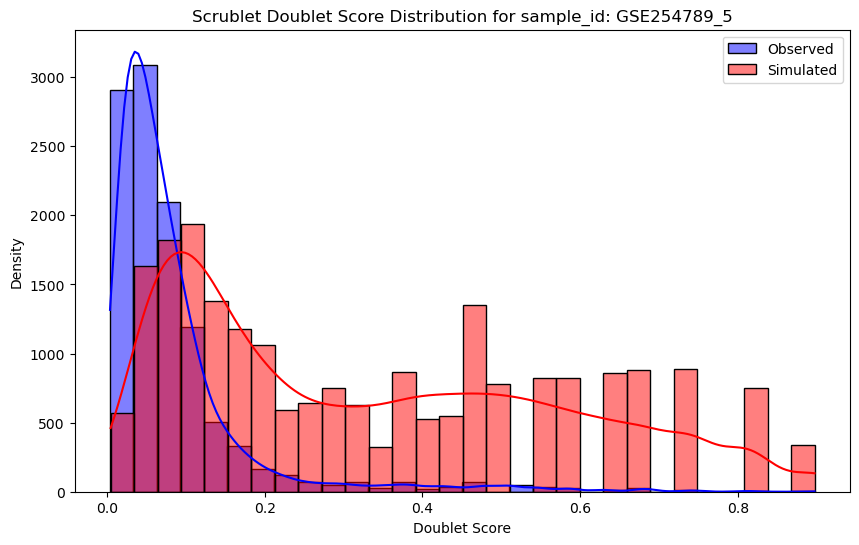

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.75
Detected doublet rate = 0.2%
Estimated detectable doublet fraction = 8.7%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 1.7%
Elapsed time: 7.7 seconds


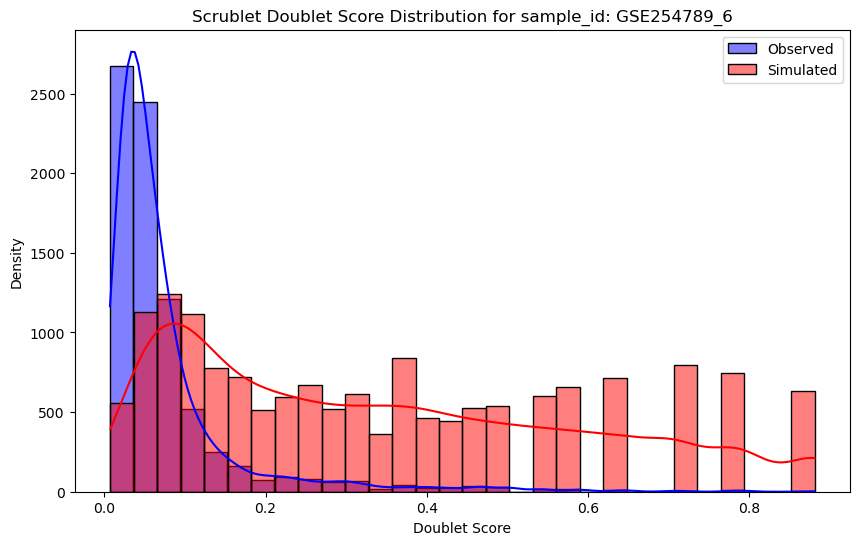

In [16]:
scrublet_result = run_scrublet(adata)

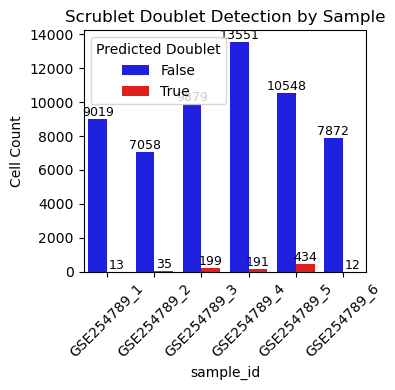

In [17]:
# Doublets flagged by Scrublet

doublet_counts = scrublet_result.groupby(['sample_id', 'Predicted_Doublet']).size().reset_index(name='count')

# Plot
plt.figure(figsize=(4, 4))
ax = sns.barplot(
    data=doublet_counts,
    x='sample_id',
    y='count',
    hue='Predicted_Doublet',
    palette={False: 'blue', True: 'red'}
)

# Add counts on bars, skip empty bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Skip zero-height bars
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9)

plt.title('Scrublet Doublet Detection by Sample')
plt.ylabel('Cell Count')
plt.legend(title='Predicted Doublet')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Normalize

In [18]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e6)
adata.layers["normalized_1e6"] = adata.X.copy()

sc.pp.log1p(adata)
adata.raw = adata.copy() # freeze log1p in raw slot
adata.layers["log1p"] = adata.X.copy()

In [19]:
adata.layers

Layers with keys: counts, normalized_1e6, log1p

In [20]:
adata

AnnData object with n_obs × n_vars = 58811 × 28694
    obs: 'GSE', 'GSM', 'sample_number', 'sample_id', 'experiment_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal', 'doublet_scores', 'predicted_doublets'
    var: 'mt', 'ribosomal', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p'
    layers: 'counts', 'normalized_1e6', 'log1p'

# Export

In [21]:
# scrublet df
scrublet_result.to_csv(scrublet_out)

In [22]:
adata.obs['predicted_doublets'] = adata.obs['predicted_doublets'].astype(bool)
adata.write(adata_out, compression = 'gzip')

In [23]:
# write to private so I can use gpu ide
temp_path = Path('/home/workspace/private/projects/kim/drg/data/scrna-seq/GSE254789-clean.h5ad')
temp_path.parent.mkdir(parents=True, exist_ok=True)
adata.write(temp_path, compression = 'gzip')

# Session info

In [24]:
print('active IDE: sc-sq')
print('active conda environment:', Path(sys.prefix).name)
session_info.show()

active IDE: sc-sq
active conda environment: sc-scrublet
